##### Stock price prediction is a challenging task in the field of finance with applications ranging from personal investment strategies to algorithmic trading. In this article we will explore how to build a stock price prediction model using TensorFlow and Long Short-Term Memory (LSTM) networks a type of recurrent neural network (RNN) which is well-suited for Timeseries data like stock prices Below is the step by step implementation:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import os
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv('all_stocks_5yr.csv', delimiter=',', on_bad_lines='skip')
print(data.shape)
print(data.sample(10))

(619040, 7)
              date    open      high       low   close   volume  Name
88599   2014-05-30   49.56   49.9925   49.3475   49.74  8678886   BMY
288461  2015-01-16  108.96  110.7500  108.9100  110.66  2532624   HSY
186613  2017-03-07   87.30   88.8500   87.1000   88.30  3016947    EA
109309  2016-08-26  107.93  110.1300  107.5000  108.79  4728358  CELG
598738  2017-06-23   56.97   57.7400   56.9700   57.31  1575807   WRK
360035  2013-04-26   41.53   42.0000   41.4800   41.57  2228607   MAR
286717  2013-02-13   17.19   17.3000   17.0700   17.15  6796391   HST
112984  2017-11-14   35.68   36.6200   35.0100   35.52  3518757    CF
214627  2017-04-18  129.99  131.0000  129.0410  130.47  1228696  EXPE
79369   2013-11-29  109.19  109.4400  108.4400  108.59   411828   BDX


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  str    
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 40.8 MB


In [5]:
data['date'] = pd.to_datetime(data['date'])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[us]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 34.9 MB


Exploratory Data Analysis

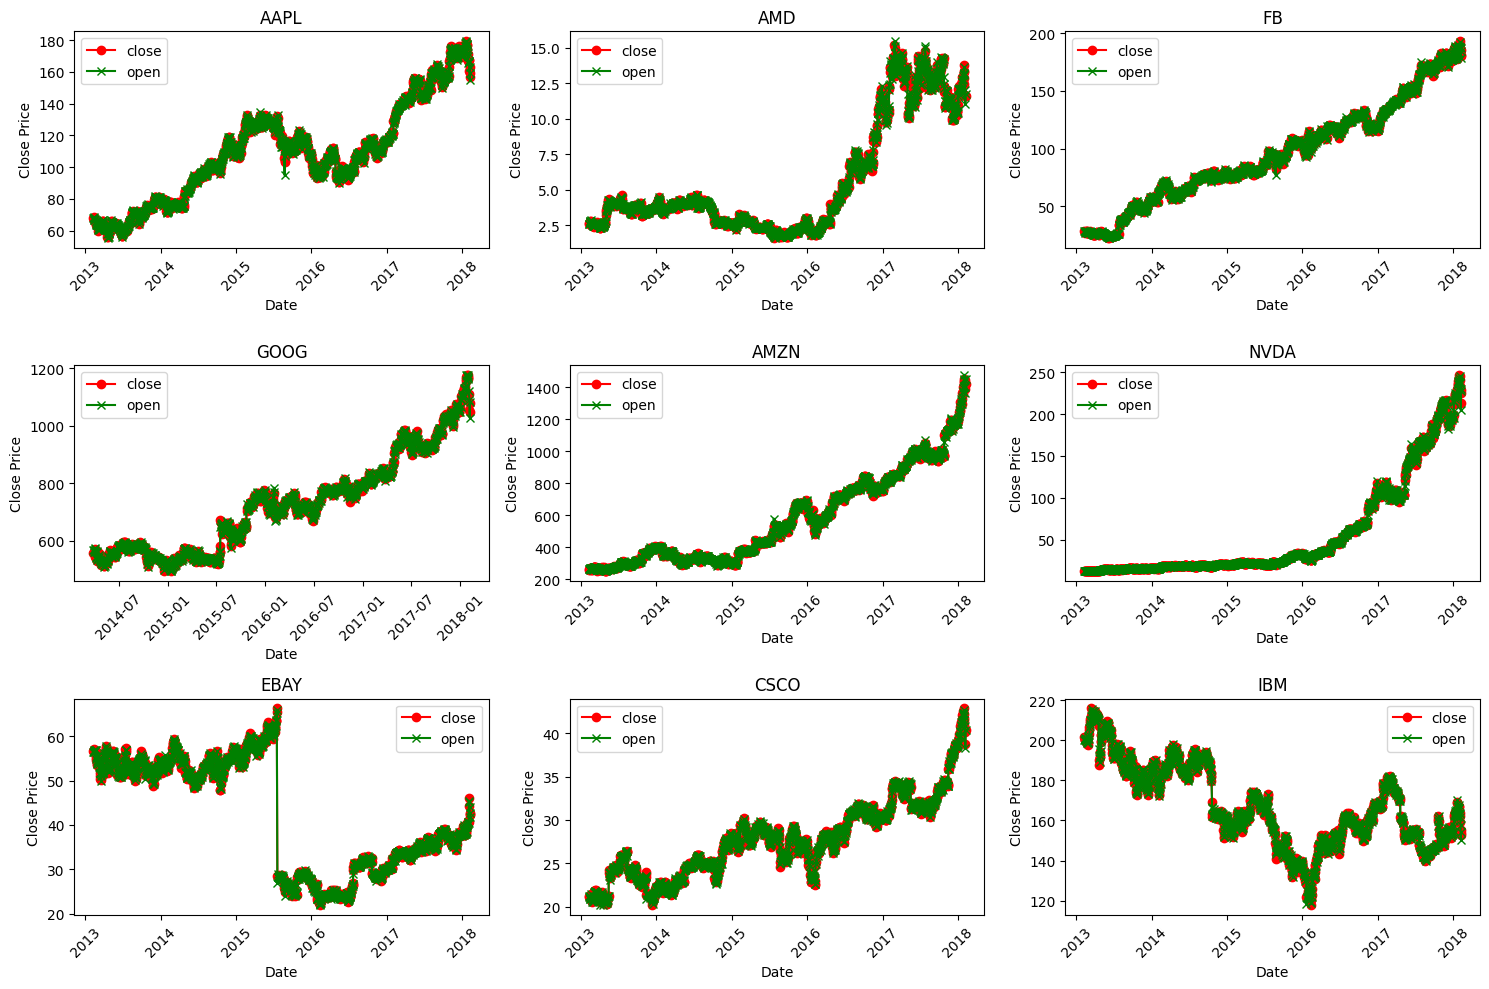

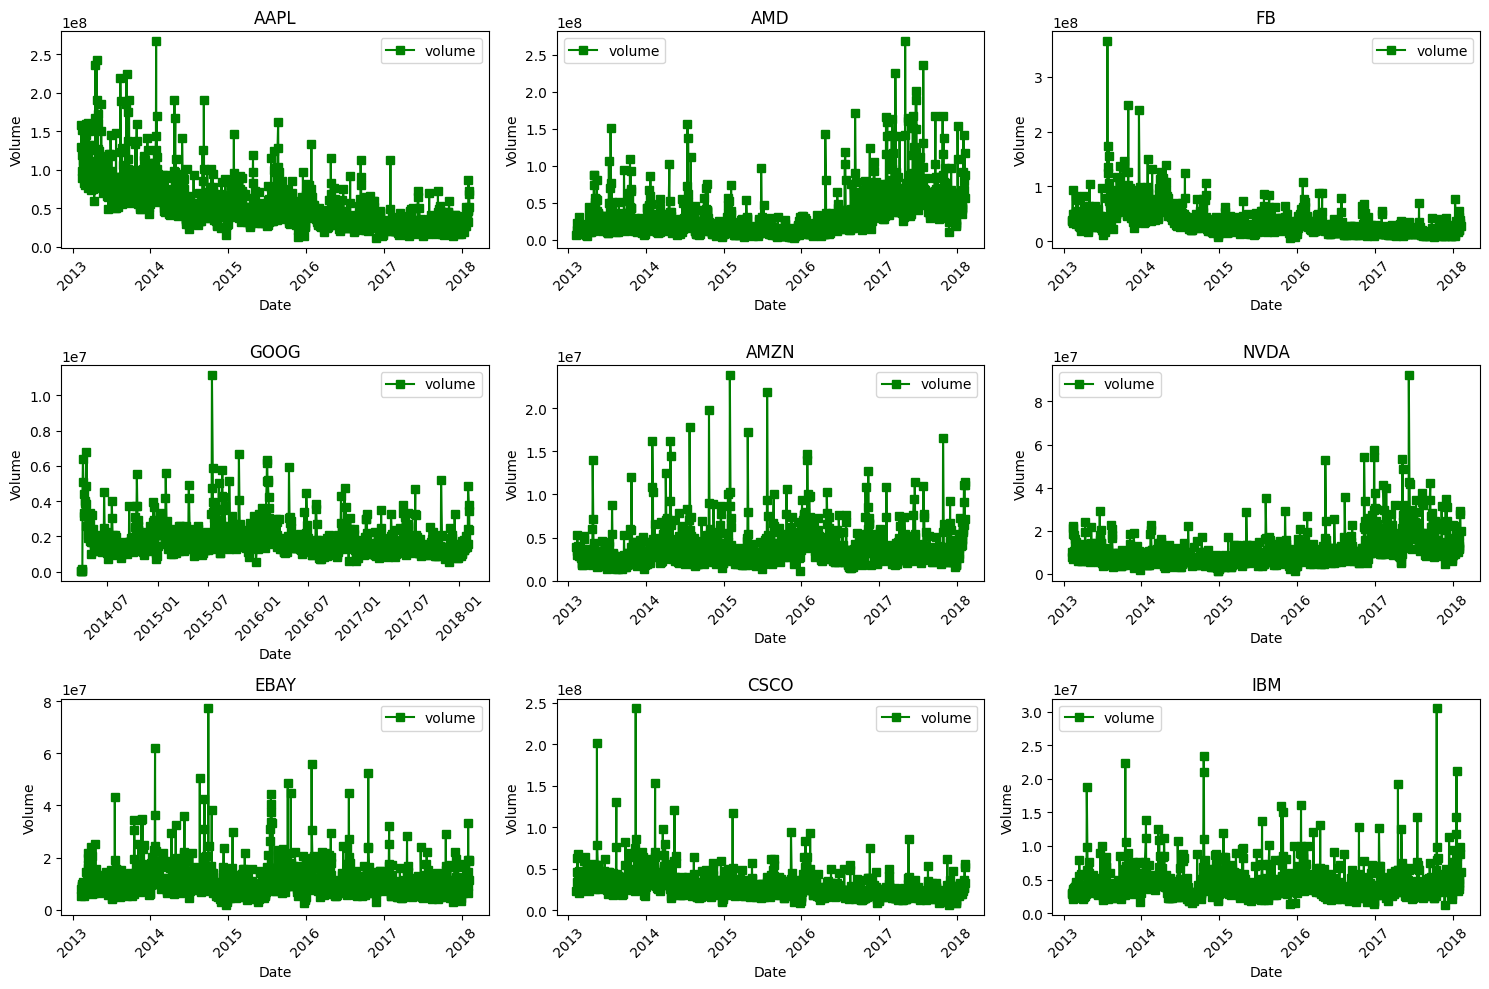

In [6]:
companies = ['AAPL', 'AMD', 'FB', 'GOOG', 'AMZN', 'NVDA', 'EBAY', 'CSCO', 'IBM']

plt.figure(figsize=(15, 10))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = data[data['Name'] == company]
    plt.plot(c['date'], c['close'], c='r', label='close', marker='o')
    plt.plot(c['date'], c['open'], c='g', label='open', marker='x')
    plt.title(company)
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.xticks(rotation=45)
    plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = data[data['Name'] == company]
    plt.plot(c['date'], c['volume'], c='g', label='volume', marker='s')
    plt.title(company)
    plt.xlabel('Date')
    plt.ylabel('Volume')
    plt.xticks(rotation=45)
    plt.legend()
plt.tight_layout()
plt.show()

Analyze the data for Apple Stocks from 2013 to 2018

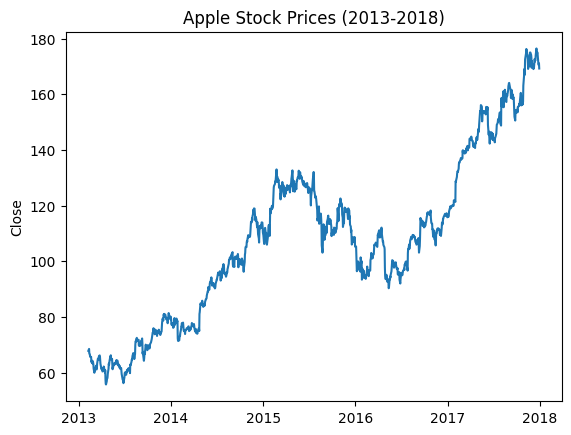

In [7]:
apple = data[data['Name'] == 'AAPL']
prediction_range = apple.loc[(apple['date'] > datetime(2013, 1, 1))
  & (apple['date'] < datetime(2018, 1, 1))]
plt.plot(prediction_range['date'], prediction_range['close'])
plt.ylabel('Close')
plt.title("Apple Stock Prices (2013-2018)")
plt.show()

In [8]:
closedata = apple.filter(['close'])
data_set = closedata.values
training_data_len = int(np.ceil(len(data_set) * .95))
print(training_data_len)

1197


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_set)

train_data = scaled_data[0:int(training_data_len), :]
# prepare feature and labels
X_train = []
y_train  = []

for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))


In [10]:
model = keras.Sequential()
model.add(keras.layers.LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(keras.layers.LSTM(units=64, return_sequences=False))
model.add(keras.layers.Dense(units=32))
model.add(keras.layers.Dense(units=16))
model.add(keras.layers.Dropout(rate=0.2))
model.add(keras.layers.Dense(units=1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,545 (205.25 KB)

 Trainable params: 52,545 (205.25 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam', loss='mean_squared_error')
history = model.fit(X_train, y_train, batch_size=1, epochs=10)

Epoch 1/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - loss: 0.0077
Epoch 2/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - loss: 0.0042
Epoch 3/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - loss: 0.0034
Epoch 4/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - loss: 0.0024
Epoch 5/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - loss: 0.0022
Epoch 6/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - loss: 0.0018
Epoch 7/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - loss: 0.0019
Epoch 8/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - loss: 0.0017
Epoch 9/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 34s 30ms/step - loss: 0.0015
Epoch 10/10
1137/1137 ━━━━━━━━━━━━━━━━━━━━ 34s 30ms/step - loss: 0.0014


In [12]:
test_data = scaled_data[training_data_len - 60:, :]
X_test = []
y_test = data_set[training_data_len:, :]
for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

mse = np.mean((predictions - y_test) ** 2)
rmse = np.sqrt(mse)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 360ms/step
Mean Squared Error: 50.02755112012108
Root Mean Squared Error: 7.073015701956351


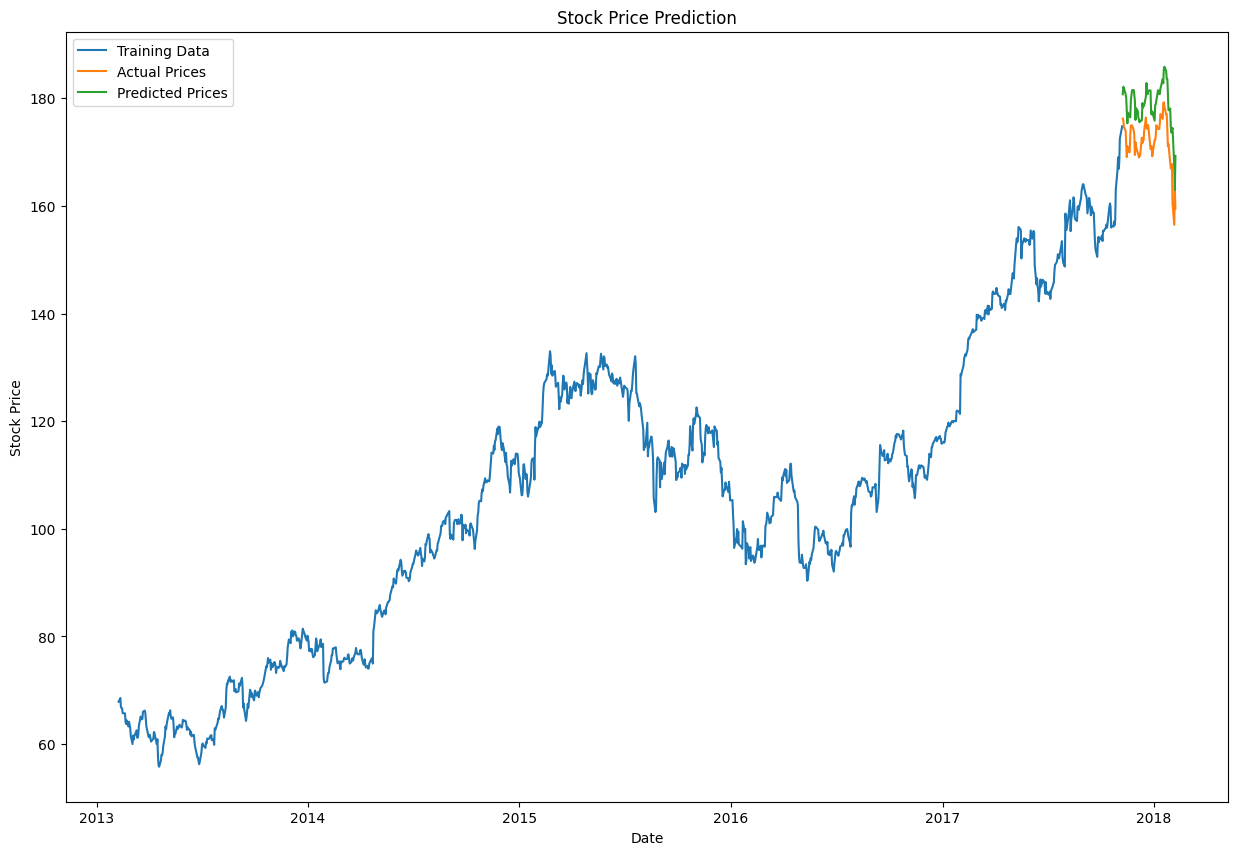

In [13]:
train = apple[:training_data_len]
test = apple[training_data_len:]
test['Predictions'] = predictions

plt.figure(figsize=(15, 10))
plt.plot(train['date'], train['close'], label='Training Data')
plt.plot(test['date'], test['close'], label='Actual Prices')
plt.plot(test['date'], test['Predictions'], label='Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Stock Price Prediction')
plt.legend()
plt.show()